# Lab 2 — Perceptron w klasyfikacji obrazów

**Wybrane Zagadnienia Sztucznej Inteligencji · II stopień**

---

## Co zrobimy na tym labie

1. **Powtórka** — wizualna intuicja perceptronu w 2D (perceptron = linijka)
2. **Hello World** — bramka AND, najprostszy możliwy przykład
3. **XOR challenge** — granica możliwości perceptronu
4. **Od 2D do obrazów** — jak MNIST 28×28 staje się 784 cechami
5. **MNIST** — klasyfikacja dwóch cyfr z ~99% accuracy
6. **Metryki** — confusion matrix, accuracy, precision, recall, F1
7. **Zadania samodzielne**

**Używamy klasy `Perceptron` z Lab 1** — nie przepisujemy jej od nowa. Importujemy z sąsiedniego folderu.

---

## 0. Setup

---

## 1. Powtórka: perceptron jako linijka w 2D

**Mental model** — to jest najważniejsza myśl z tego laba:

> **Perceptron to linijka, którą próbujesz położyć tak, żeby oddzielić dwa rodzaje punktów.**

- W 2D (2 cechy) — perceptron rysuje **prostą**
- W 3D (3 cechy) — perceptron rysuje **płaszczyznę**
- W 784D (piksele MNIST) — perceptron rysuje **hiperpłaszczyznę**

Nie da się wyobrazić sobie 784 wymiarów, ale **matematyka działa tak samo** niezależnie od liczby wymiarów. Zaczynamy od 2D, żeby zobaczyć co się dzieje.

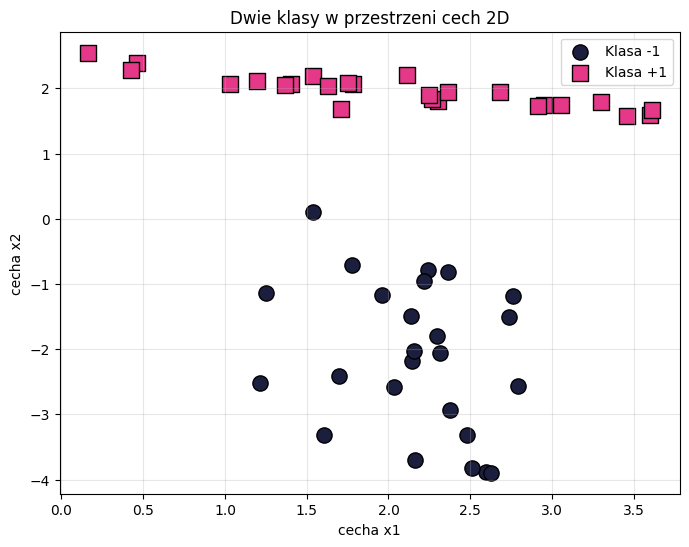

Liczba próbek: 50
Kształt X:     (50, 2)
Klasy:         [-1  1]


In [2]:
# Generujemy losowy zbiór 2D z dwoma klasami
from sklearn.datasets import make_classification

X_toy, y_toy = make_classification(
    n_samples=50, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    flip_y=0, class_sep=2.0, random_state=42
)
# Konwersja 0/1 -> -1/+1 (nasza klasa Perceptron używa tej konwencji)
y_toy = np.where(y_toy == 0, -1, 1)

plt.figure(figsize=(8, 6))
plt.scatter(X_toy[y_toy == -1, 0], X_toy[y_toy == -1, 1],
            c='#1B1E3D', marker='o', label='Klasa -1', edgecolor='black', s=120)
plt.scatter(X_toy[y_toy == 1, 0], X_toy[y_toy == 1, 1],
            c='#E63888', marker='s', label='Klasa +1', edgecolor='black', s=120)
plt.xlabel('cecha x1')
plt.ylabel('cecha x2')
plt.title('Dwie klasy w przestrzeni cech 2D')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'Liczba próbek: {len(X_toy)}')
print(f'Kształt X:     {X_toy.shape}')
print(f'Klasy:         {np.unique(y_toy)}')

**Pytanie do siebie:** czy da się oddzielić te punkty **jedną** linią? Jeśli tak — dane są **liniowo separowalne** i perceptron sobie poradzi.

Spróbujmy:

Błędy w kolejnych epokach: [2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Końcowe wagi: [-0.18375655 -0.29742122  1.13977275]


/Users/macbook/Desktop/WSEI EDU/BAI_LAB_TASKS/lab1_perceptron/pdr.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


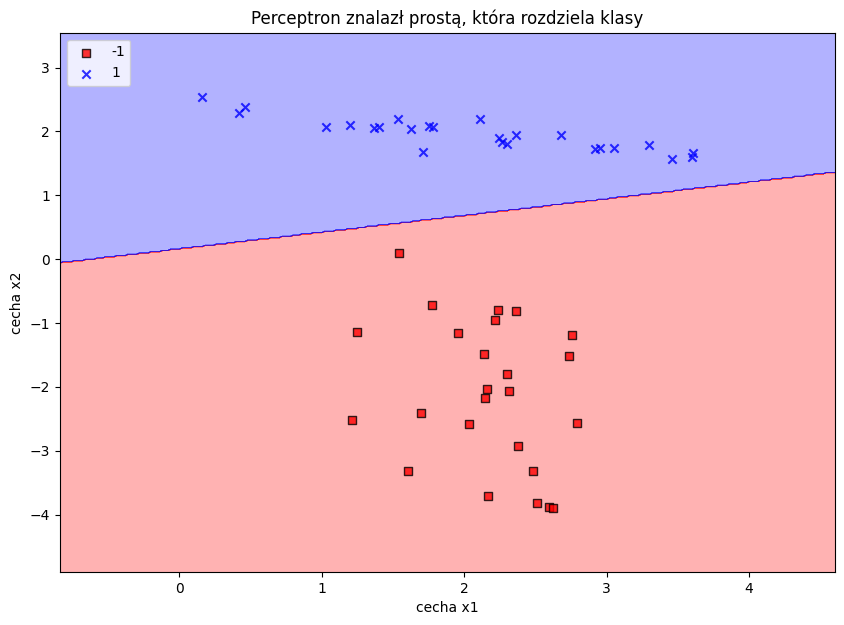

In [3]:
# Trenujemy perceptron z Lab 1
model_toy = Perceptron(eta=0.1, n_iter=20)
model_toy.fit(X_toy, y_toy)

print(f'Błędy w kolejnych epokach: {model_toy.errors_}')
print(f'Końcowe wagi: {model_toy.w_}')

# Rysujemy regiony decyzyjne używając pdr.plot_decision_regions z Lab 1
plt.figure(figsize=(10, 7))
pdr.plot_decision_regions(X_toy, y_toy, classifier=model_toy)
plt.xlabel('cecha x1')
plt.ylabel('cecha x2')
plt.title('Perceptron znalazł prostą, która rozdziela klasy')
plt.legend(loc='upper left')
plt.show()

### Krzywa błędu — jak perceptron się uczy

Perceptron ma atrybut `errors_` — lista liczby błędnych klasyfikacji po każdej epoce.

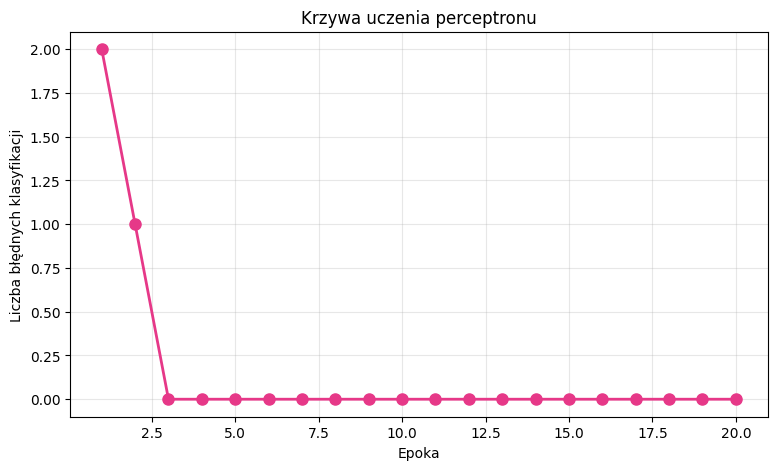

Po 20 epokach mamy 0 błędów
Jeśli spadło do zera — perceptron idealnie rozdzielił klasy (dane są liniowo separowalne)


In [4]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(model_toy.errors_) + 1), model_toy.errors_,
         marker='o', color='#E63888', linewidth=2, markersize=8)
plt.xlabel('Epoka')
plt.ylabel('Liczba błędnych klasyfikacji')
plt.title('Krzywa uczenia perceptronu')
plt.grid(alpha=0.3)
plt.show()

print(f'Po {len(model_toy.errors_)} epokach mamy {model_toy.errors_[-1]} błędów')
print('Jeśli spadło do zera — perceptron idealnie rozdzielił klasy (dane są liniowo separowalne)')

---

## 2. Hello World: bramka AND

Najprostszy możliwy przykład klasyfikacji. Bramka AND ma tylko 4 możliwe wejścia:

| x1 | x2 | AND |
|----|----|----|
| 0  | 0  | 0  |
| 0  | 1  | 0  |
| 1  | 0  | 0  |
| 1  | 1  | 1  |

**Tylko gdy oba wejścia są 1, wyjście jest 1.**

Mamy gotowy plik `logic_gates.csv` w Lab 1 — załadujmy go.

In [5]:
gates = pd.read_csv('./lab1_perceptron/data/logic_gates.csv')
print(gates)

   x1  x2  and  or  xor
0   0   0    0   0    0
1   0   1    0   1    1
2   1   0    0   1    1
3   1   1    1   1    0


**Przygotowanie danych dla perceptronu:**
- `X` = kolumny `x1`, `x2`
- `y` = kolumna `and`, ale **zamieniona z 0/1 na -1/+1** (bo klasa Perceptron z Lab 1 używa tej konwencji!)

⚠️ **To jest pułapka #1**: jeśli zostawisz 0/1, perceptron nie będzie działał — bo jego `predict` zwraca -1/+1.

In [6]:
X_and = gates[['x1', 'x2']].values
y_and = gates['and'].values
y_and = np.where(y_and == 0, -1, 1)   # 0 -> -1, 1 -> +1

print('X (wejścia):')
print(X_and)
print()
print('y (etykiety -1/+1):')
print(y_and)

X (wejścia):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

y (etykiety -1/+1):
[-1 -1 -1  1]


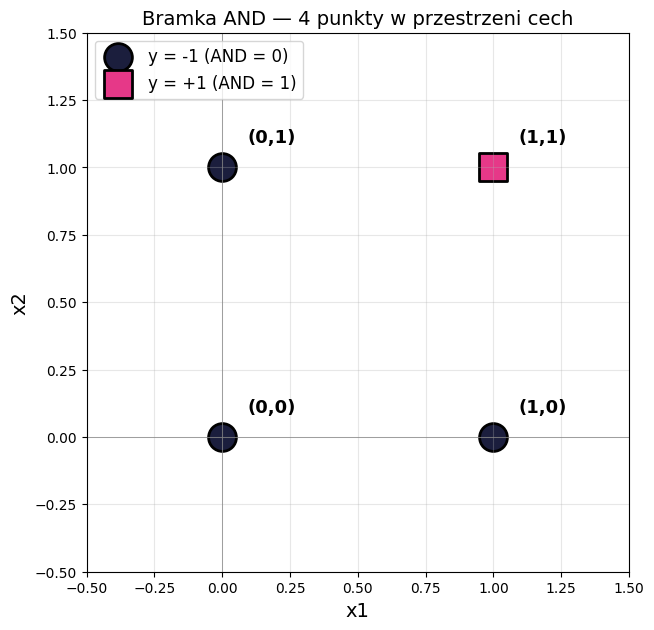

Pytanie: czy da się oddzielić czerwony kwadrat od niebieskich kółek JEDNĄ linią?


In [7]:
# Rysujemy 4 punkty AND
plt.figure(figsize=(7, 7))
plt.scatter(X_and[y_and == -1, 0], X_and[y_and == -1, 1],
            c='#1B1E3D', marker='o', s=400, label='y = -1 (AND = 0)',
            edgecolor='black', linewidth=2)
plt.scatter(X_and[y_and == 1, 0], X_and[y_and == 1, 1],
            c='#E63888', marker='s', s=400, label='y = +1 (AND = 1)',
            edgecolor='black', linewidth=2)

for x, y in X_and:
    plt.annotate(f'({x},{y})', (x, y),
                 textcoords='offset points', xytext=(18, 18),
                 fontsize=13, fontweight='bold')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('x1', fontsize=14)
plt.ylabel('x2', fontsize=14)
plt.title('Bramka AND — 4 punkty w przestrzeni cech', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(alpha=0.3)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.show()

print('Pytanie: czy da się oddzielić czerwony kwadrat od niebieskich kółek JEDNĄ linią?')

In [8]:
# Trenujemy perceptron na bramce AND
model_and = Perceptron(eta=0.1, n_iter=10)
model_and.fit(X_and, y_and)

print(f'Krzywa błędu: {model_and.errors_}')
print(f'Końcowe wagi: {model_and.w_}')
print()

# Sprawdzamy każdą predykcję
print('Test predykcji dla wszystkich 4 przypadków:')
for xi, yi in zip(X_and, y_and):
    pred = model_and.predict(xi)
    status = 'OK' if pred == yi else 'ZLY'
    print(f'  x={xi}, target={yi:+d}, predykcja={pred:+d}  [{status}]')

Krzywa błędu: [2, 3, 3, 2, 1, 0, 0, 0, 0, 0]
Końcowe wagi: [-0.58375655  0.39388244  0.19471828]

Test predykcji dla wszystkich 4 przypadków:
  x=[0 0], target=-1, predykcja=-1  [OK]
  x=[0 1], target=-1, predykcja=-1  [OK]
  x=[1 0], target=-1, predykcja=-1  [OK]
  x=[1 1], target=+1, predykcja=+1  [OK]


/Users/macbook/Desktop/WSEI EDU/BAI_LAB_TASKS/lab1_perceptron/pdr.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


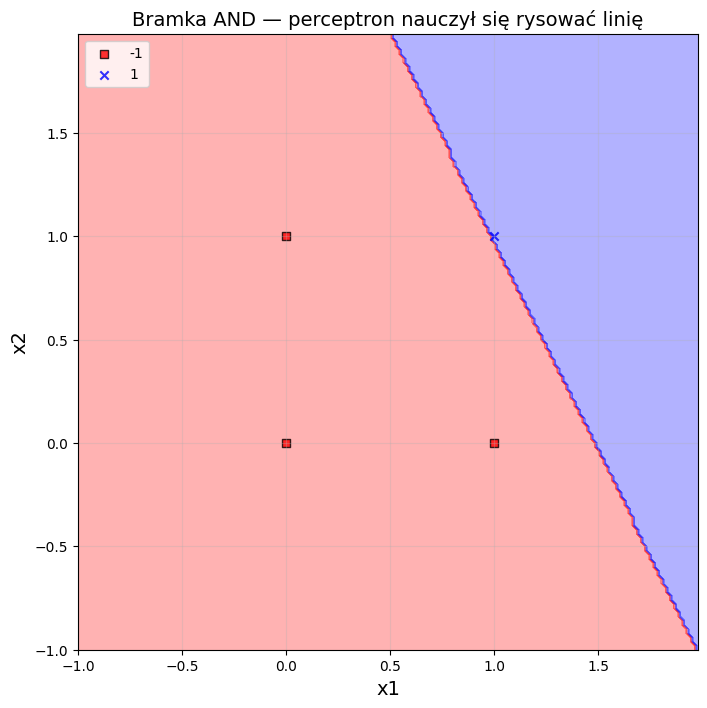

In [9]:
# Wizualizacja regionów decyzyjnych — tu widać linię którą perceptron narysował
plt.figure(figsize=(8, 8))
pdr.plot_decision_regions(X_and, y_and, classifier=model_and)
plt.xlabel('x1', fontsize=14)
plt.ylabel('x2', fontsize=14)
plt.title('Bramka AND — perceptron nauczył się rysować linię', fontsize=14)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.show()

**Udało się!** Perceptron nauczył się AND. Patrzymy na obrazek: jest linia, po jednej stronie (ciemny obszar) klasa -1, po drugiej (jaśniejszy obszar) klasa +1. Cztery punkty po właściwych stronach.

### ✏️ Ćwiczenie w locie: bramka OR

Bramka OR: (0,0)→0, reszta → 1. Też jest liniowo separowalna (3 "czerwone" punkty, 1 "niebieski").

Skopiuj kod z bramki AND i zmień `gates['and']` na `gates['or']`.

In [10]:
# Ćwiczenie w locie: bramka OR
# OR: (0,0)->0, reszta -> 1

# 1. Pobieramy etykiety OR
y_or = gates['or'].values

# 2. Konwersja 0 -> -1, 1 -> +1
y_or = np.where(y_or == 0, -1, 1)

print('Dane bramki OR:')
for xi, yi in zip(gates[["x1", "x2"]].values, y_or):
    print(f'  x1={int(xi[0])}, x2={int(xi[1])}  ->  y={yi}')

# 3. Tworzymy i trenujemy perceptron (X jest ten sam co dla AND)
X_or = gates[["x1", "x2"]].values
model_or = Perceptron(eta=0.1, n_iter=10)
model_or.fit(X_or, y_or)

print(f"Krzywa błędu: {model_or.errors_}")
print(f"Końcowe wagi: {model_or.w_}")

# 4. Sprawdzamy każdą predykcję
print("
Test predykcji:")
for xi, yi in zip(X_or, y_or):
    pred = model_or.predict(xi.reshape(1, -1))
    status = "OK" if pred[0] == yi else "BLAD"
    print(f"  x={xi} -> pred={pred[0]:+d}, expected={yi:+d}  {status}")

# 5. Wizualizacja regionów decyzyjnych
plt.figure(figsize=(8, 8))
pdr.plot_decision_regions(X_or, y_or, classifier=model_or)
plt.xlabel("x1", fontsize=14)
plt.ylabel("x2", fontsize=14)
plt.title("Bramka OR — regiony decyzyjne perceptronu", fontsize=14)
plt.tight_layout()
plt.show()

---

## 3. XOR — tu perceptron się poddaje

Teraz bramka **XOR** (exclusive OR):

| x1 | x2 | XOR |
|----|----|----|
| 0  | 0  | 0  |
| 0  | 1  | 1  |
| 1  | 0  | 1  |
| 1  | 1  | 0  |

Wyjście jest 1 gdy **dokładnie jedno** z wejść jest 1.

### 🎬 Historia

W **1969 roku** Marvin Minsky i Seymour Papert opublikowali książkę *Perceptrons*, w której pokazali, że pojedynczy perceptron **nie umie** nauczyć się funkcji XOR.

To odkrycie zabiło badania nad sieciami neuronowymi na **prawie 20 lat** — okres znany jako **"AI Winter"**. Dopiero w latach 80. wrócono do wielowarstwowych sieci (z backpropagation), które umieją XOR. Na następnym labie to zobaczycie.

Zobaczmy dlaczego XOR jest niemożliwy dla perceptronu.

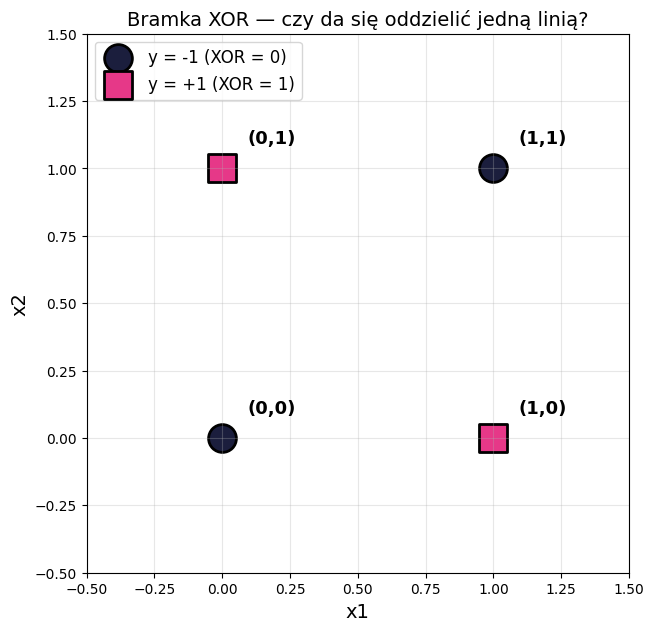

Niebieskie są w dwóch przeciwległych rogach, czerwone w drugich przeciwległych.
Spróbuj narysować JEDNĄ linię, która je rozdzieli. Nie da się.


In [11]:
X_xor = gates[['x1', 'x2']].values
y_xor = gates['xor'].values
y_xor = np.where(y_xor == 0, -1, 1)

plt.figure(figsize=(7, 7))
plt.scatter(X_xor[y_xor == -1, 0], X_xor[y_xor == -1, 1],
            c='#1B1E3D', marker='o', s=400, label='y = -1 (XOR = 0)',
            edgecolor='black', linewidth=2)
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1],
            c='#E63888', marker='s', s=400, label='y = +1 (XOR = 1)',
            edgecolor='black', linewidth=2)

for x, y in X_xor:
    plt.annotate(f'({x},{y})', (x, y),
                 textcoords='offset points', xytext=(18, 18),
                 fontsize=13, fontweight='bold')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xlabel('x1', fontsize=14)
plt.ylabel('x2', fontsize=14)
plt.title('Bramka XOR — czy da się oddzielić jedną linią?', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(alpha=0.3)
plt.show()

print('Niebieskie są w dwóch przeciwległych rogach, czerwone w drugich przeciwległych.')
print('Spróbuj narysować JEDNĄ linię, która je rozdzieli. Nie da się.')

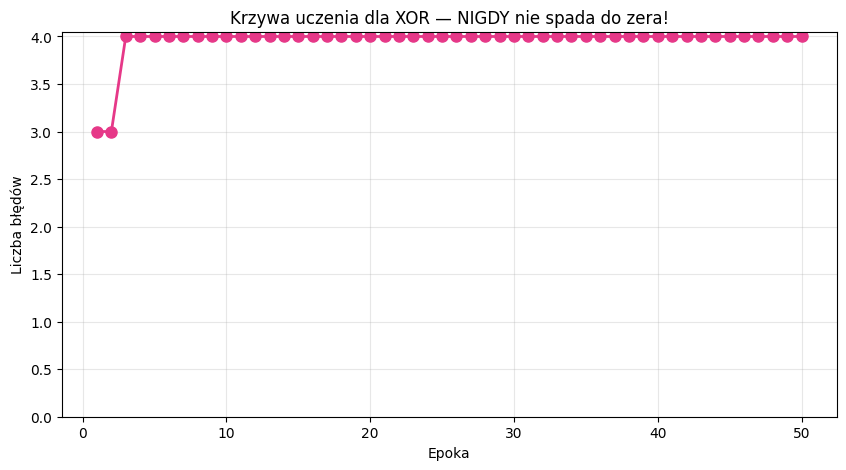

Błędy w kolejnych epokach: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]

Błąd nigdy nie spada do zera. Perceptron oscyluje, bo XOR jest matematycznie niemożliwy
do oddzielenia jedną linią (nie jest liniowo separowalny).

Rozwiązanie: wielowarstwowe sieci neuronowe (MLP) - zobaczymy na Lab 3.


In [12]:
# Spróbujmy jednak wytrenować perceptron na XOR — co się stanie?
model_xor = Perceptron(eta=0.1, n_iter=50)
model_xor.fit(X_xor, y_xor)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(model_xor.errors_) + 1), model_xor.errors_,
         marker='o', color='#E63888', linewidth=2, markersize=8)
plt.xlabel('Epoka')
plt.ylabel('Liczba błędów')
plt.title('Krzywa uczenia dla XOR — NIGDY nie spada do zera!')
plt.grid(alpha=0.3)
plt.ylim(bottom=0)
plt.show()

print(f'Błędy w kolejnych epokach: {model_xor.errors_}')
print()
print('Błąd nigdy nie spada do zera. Perceptron oscyluje, bo XOR jest matematycznie niemożliwy')
print('do oddzielenia jedną linią (nie jest liniowo separowalny).')
print()
print('Rozwiązanie: wielowarstwowe sieci neuronowe (MLP) - zobaczymy na Lab 3.')

### 💡 Perceptron Convergence Theorem

Rosenblatt udowodnił (1962) twierdzenie:

> **Jeśli dane są liniowo separowalne, algorytm perceptronu ZAWSZE znajdzie rozwiązanie w skończonej liczbie kroków.**

Ale: **jeśli nie są separowalne — algorytm nigdy się nie zatrzyma**. Będzie wiecznie poprawiał i psuł. Dlatego XOR nie zbiega do zera.

W praktyce: jeśli widzisz że błąd nie spada — to nie znaczy że źle napisałeś kod. To może znaczyć że **dane nie są liniowo separowalne**.

---

## 4. Od 2D do obrazów — klucz do MNIST

Do tej pory perceptron miał **2 wejścia** — bo mogliśmy rysować punkty na płaszczyźnie. MNIST ma obrazy **28×28 pikseli**. Jak z tego zrobić wejścia dla perceptronu?

### Spłaszczanie (flattening)

Bierzemy obraz 28×28 i **układamy go wiersz po wierszu w jeden długi wektor**. Dostajemy 28 × 28 = **784 liczby**. Każdy piksel = jedna cecha.

```
Obraz 28×28:           Wektor 1D (784):
[[  0,   0,   0, ...],     [  0,   0,   0, ..., 128, 255, ..., 0]
 [  0, 128, 255, ...], →    (784 liczby)
 [  0, 255, 200, ...],
 ...                  ]
```

W Pythonie: `image.flatten()` albo `image.reshape(-1)`. Macierz → wektor.

### ⚠️ Kluczowa obserwacja

**Perceptron nie wie, że to obraz.** Dla niego to po prostu 784 liczby. Piksel (5, 10) i piksel (5, 11) nie są dla niego bardziej "sąsiednie" niż piksel (5, 10) i piksel (22, 3). Ignoruje **sąsiedztwo pikseli**.

Gdybyśmy wszystkie obrazy przetasowali w ten sam sposób (zachowując mapping), perceptron nauczyłby się **tak samo dobrze**. To dlatego perceptron działa na prostych parach cyfr w MNIST, ale źle na trudnych obrazach. Dopiero **sieci konwolucyjne (CNN)** uwzględniają sąsiedztwo — ale to temat na później w semestrze.

---

## 5. MNIST — klasyfikacja obrazów cyfr

**MNIST** = Modified National Institute of Standards and Technology.

Klasyczny zbiór danych w ML: 70 000 obrazków cyfr odręcznych 0-9, każdy **28×28 pikseli** w skali szarości (0-255). Historycznie był "hello world" deep learningu.

Mamy go już w `lab1_perceptron/data/`.

### Wczytanie

In [13]:
train_df = pd.read_csv('./lab1_perceptron/data/mnist_train.csv')
test_df = pd.read_csv('./lab1_perceptron/data/mnist_test.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
print()
print('Pierwsze 5 wierszy (label + pierwsze 5 pikseli):')
print(train_df.iloc[:5, :6])
print()
print(f'Dostępne klasy: {sorted(train_df["label"].unique())}')

Train shape: (5000, 785)
Test shape:  (1000, 785)

Pierwsze 5 wierszy (label + pierwsze 5 pikseli):
   label  pixel1  pixel2  pixel3  pixel4  pixel5
0      8       0       0       0       0       0
1      4       0       0       0       0       0
2      8       0       0       0       0       0
3      7       0       0       0       0       0
4      7       0       0       0       0       0

Dostępne klasy: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Podgląd kilku obrazków

Każdy wiersz to: label + 784 wartości pikseli (od `pixel1` do `pixel784`). Żeby wyświetlić jako obraz, musimy z powrotem uformować wektor w kształt 28×28.

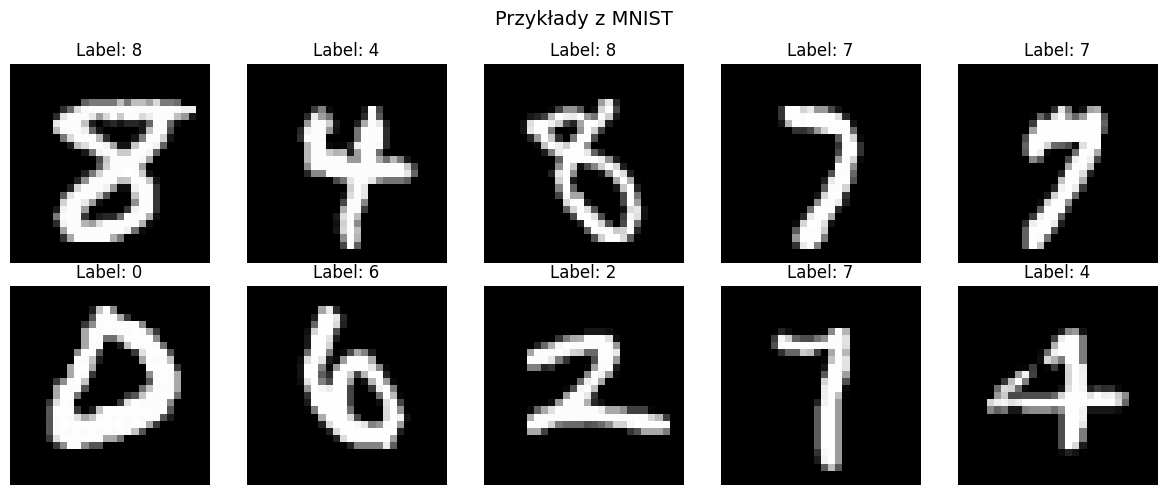

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    row = train_df.iloc[i]
    label = row['label']
    # Pierwsza kolumna to label, reszta (1:) to 784 piksele
    pixels = row[1:].values.reshape(28, 28)
    ax.imshow(pixels, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Przykłady z MNIST', fontsize=14)
plt.tight_layout()
plt.show()

### Filtrujemy do 2 wybranych cyfr

Perceptron jest **binarnym** klasyfikatorem. Nie umie rozpoznawać 10 cyfr. Wybieramy więc **2 cyfry** i uczymy perceptron je rozróżniać.

Wybieramy **3** i **4** (dobrze się rozróżniają). Binaryzujemy etykiety:
- cyfra **3** → `-1`
- cyfra **4** → `+1`

In [15]:
DIGIT_A = 3   # etykieta -1
DIGIT_B = 4   # etykieta +1

# Filtrujemy tylko wiersze z wybranymi cyframi
mask_train = train_df['label'].isin([DIGIT_A, DIGIT_B])
mask_test = test_df['label'].isin([DIGIT_A, DIGIT_B])

train_filtered = train_df[mask_train].copy()
test_filtered = test_df[mask_test].copy()

# X = piksele (wszystkie kolumny poza pierwszą), y = label (pierwsza kolumna)
X_train = train_filtered.iloc[:, 1:].values.astype(np.float32)
y_train = train_filtered.iloc[:, 0].values

X_test = test_filtered.iloc[:, 1:].values.astype(np.float32)
y_test = test_filtered.iloc[:, 0].values

# Binaryzacja: DIGIT_A -> -1, DIGIT_B -> +1
y_train = np.where(y_train == DIGIT_A, -1, 1)
y_test = np.where(y_test == DIGIT_A, -1, 1)

print(f'X_train shape: {X_train.shape}   (n_samples × 784 pikseli)')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_test shape:  {y_test.shape}')
print()
print(f'Klasa -1 (cyfra {DIGIT_A}): {np.sum(y_train == -1)} próbek w train')
print(f'Klasa +1 (cyfra {DIGIT_B}): {np.sum(y_train == 1)} próbek w train')

X_train shape: (989, 784)   (n_samples × 784 pikseli)
y_train shape: (989,)
X_test shape:  (207, 784)
y_test shape:  (207,)

Klasa -1 (cyfra 3): 556 próbek w train
Klasa +1 (cyfra 4): 433 próbek w train


### Normalizacja

Wartości pikseli to 0-255. **Dzielimy przez 255** żeby były w zakresie [0, 1].

**Dlaczego?** Bo duże wartości (255) × wagi = eksplozja. Perceptron zaczyna oscylować zamiast się uczyć. Skalowanie do [0, 1] to **standardowa praktyka** w ML — dotyczy wszystkich modeli, nie tylko perceptronu.

⚠️ **To jest pułapka #2**: jeśli zapomnisz o normalizacji, dostaniesz accuracy ~50% (losowe zgadywanie).

In [16]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f'Zakres X_train po normalizacji: [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'Shape nadal: {X_train.shape}')

Zakres X_train po normalizacji: [0.00, 1.00]
Shape nadal: (989, 784)


### Trening

Używamy tej samej klasy `Perceptron` co dla bramek logicznych. Tylko teraz ma 784 wejścia zamiast 2. **Algorytm jest identyczny** — perceptron nadal rysuje (hiper)płaszczyznę w przestrzeni cech.

Trening na ~12 000 próbkach zajmie ~15 sekund.

In [17]:
model_mnist = Perceptron(eta=0.01, n_iter=30)

print('Trenuje perceptron na MNIST... (to moze potrwac ~15s)')
model_mnist.fit(X_train, y_train)
print('Gotowe.')
print()
print(f'Liczba błędów per epoka: {model_mnist.errors_}')

Trenuje perceptron na MNIST... (to moze potrwac ~15s)
Gotowe.

Liczba błędów per epoka: [35, 8, 8, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


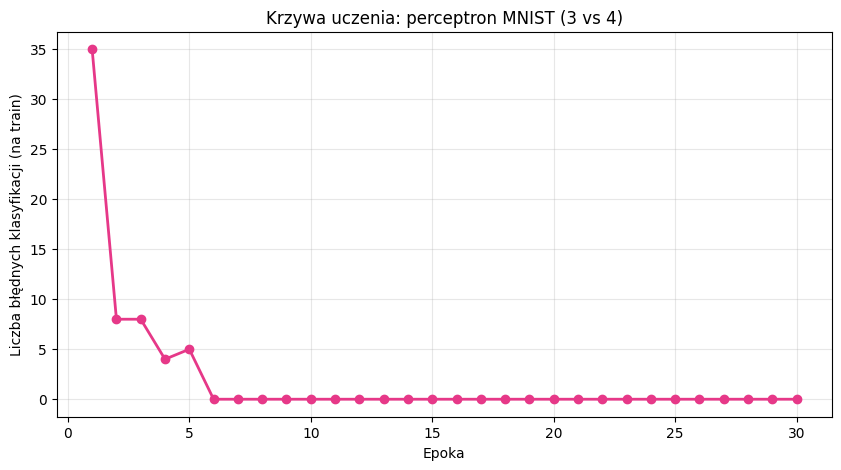

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(model_mnist.errors_) + 1), model_mnist.errors_,
         marker='o', color='#E63888', linewidth=2, markersize=6)
plt.xlabel('Epoka')
plt.ylabel('Liczba błędnych klasyfikacji (na train)')
plt.title(f'Krzywa uczenia: perceptron MNIST ({DIGIT_A} vs {DIGIT_B})')
plt.grid(alpha=0.3)
plt.show()

---

## 6. Ewaluacja na zbiorze testowym

In [19]:
y_pred = model_mnist.predict(X_test)

n_wrong = np.sum(y_pred != y_test)
n_total = len(y_test)
print(f'Błędnych klasyfikacji: {n_wrong} / {n_total}')
print(f'Accuracy: {(n_total - n_wrong) / n_total:.4f}')

Błędnych klasyfikacji: 0 / 207
Accuracy: 1.0000


### Confusion matrix

Macierz pomyłek pokazuje **gdzie** model się myli. To tabela 2×2:

|              | Predicted: -1 | Predicted: +1 |
|--------------|---------------|---------------|
| **Actual: -1** | TN (True Negative) | FP (False Positive) |
| **Actual: +1** | FN (False Negative) | TP (True Positive) |

- **TP** — miało być +1, model powiedział +1 ✓
- **TN** — miało być -1, model powiedział -1 ✓
- **FP** — miało być -1, ale model powiedział +1 ✗ (fałszywy alarm)
- **FN** — miało być +1, ale model powiedział -1 ✗ (przegapiony)

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:')
print(f'                  pred=-1 ({DIGIT_A})   pred=+1 ({DIGIT_B})')
print(f'actual=-1 ({DIGIT_A}):     {cm[0,0]:5d}          {cm[0,1]:5d}')
print(f'actual=+1 ({DIGIT_B}):     {cm[1,0]:5d}          {cm[1,1]:5d}')
print()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 score:  {f1:.4f}')

Confusion matrix:
                  pred=-1 (3)   pred=+1 (4)
actual=-1 (3):       119              0
actual=+1 (4):         0             88

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 score:  1.0000


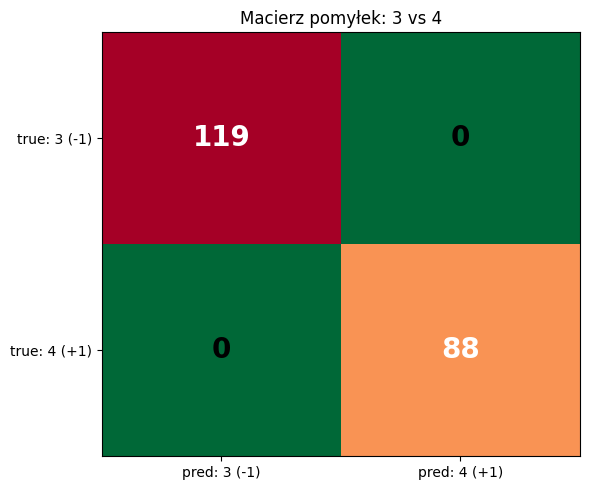

In [21]:
# Wizualna confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([f'pred: {DIGIT_A} (-1)', f'pred: {DIGIT_B} (+1)'])
ax.set_yticklabels([f'true: {DIGIT_A} (-1)', f'true: {DIGIT_B} (+1)'])

for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center',
                color=text_color, fontsize=20, fontweight='bold')

ax.set_title(f'Macierz pomyłek: {DIGIT_A} vs {DIGIT_B}')
plt.tight_layout()
plt.show()

### Co oznaczają metryki?

**Accuracy** = (poprawne) / (wszystkie)
- Proste. Ale **mylące przy niezbalansowanych klasach** — jeśli masz 99% cyfr A i 1% B, model który zawsze mówi "A" ma 99% accuracy, ale jest bezużyteczny.

**Precision** = TP / (TP + FP)
- *Z tych które model nazwał '+1', ile naprawdę było '+1'?*
- Ważne gdy fałszywy alarm kosztuje dużo (np. filtrowanie spamu — nie chcesz by ważny email wylądował w spamie).

**Recall** = TP / (TP + FN)
- *Ze wszystkich prawdziwych '+1', ile model złapał?*
- Ważne gdy przegapienie kosztuje dużo (np. wykrywanie raka — lepiej mieć fałszywe alarmy niż przegapić prawdziwy przypadek).

**F1** = średnia harmoniczna precision i recall
- Kompromis. Używamy gdy nie wiemy co jest ważniejsze.
- **Dlaczego harmoniczna?** Bo "karze" nierówności. Jeśli precision=1.0 a recall=0.0, arytmetyczna dałaby 0.5 (niby OK), harmoniczna daje 0 (słusznie źle).

Dla 3 vs 4 wszystkie metryki powinny być ~99% bo dane są zbalansowane i liniowo separowalne. W prawdziwym świecie rzadko tak dobrze.

---

## 7. Najczęstsze błędy (wracaj tutaj gdy utkniesz)

### 🔴 Błąd 1: Zapomniana normalizacja
**Objaw:** accuracy ~50% (jak losowanie monetą)  
**Fix:** `X = X / 255.0` po załadowaniu danych

### 🔴 Błąd 2: Etykiety 0/1 zamiast -1/+1
**Objaw:** accuracy ~50%, confusion matrix wygląda losowo  
**Fix:** `y = np.where(y == 0, -1, 1)`. Klasa `Perceptron` z Lab 1 używa konwencji -1/+1, nie 0/1. Metoda `.predict()` zwraca -1/+1, więc porównanie z 0/1 będzie zawsze nieprawdą.

### 🔴 Błąd 3: Zły shape po filtrowaniu
**Objaw:** `ValueError: shapes (784,) and (n, 28, 28) not aligned`  
**Fix:** `X.shape` musi być `(n_samples, 784)`, nie `(n_samples, 28, 28)`. Dane z CSV są już spłaszczone — nie musisz robić `.reshape()`.

### 🔴 Błąd 4: Za mało epok
**Objaw:** krzywa błędu jeszcze spada na końcu, accuracy jest niższy niż oczekiwano  
**Fix:** zwiększ `n_iter` w konstruktorze Perceptron. Patrz na krzywą — gdy przestaje spadać, to jest twój n_iter.

---

## 8. Zadania samodzielne

### Zadanie 1: Bramka OR

Wzoruj się na bramce AND z sekcji 2. Wytrenuj perceptron na bramce OR i zwizualizuj regiony decyzyjne.

**Spodziewany wynik:** perceptron uczy się OR w kilku epokach.

In [ ]:
# Zadanie 1 — bramka OR

# 1. Wczytaj y_or z gates['or']
y_or = gates['or'].values

# 2. Konwertuj 0 -> -1, 1 -> +1
y_or = np.where(y_or == 0, -1, 1)

X_or = gates[["x1", "x2"]].values

print("Dane bramki OR (po konwersji etykiet):")
for xi, yi in zip(X_or, y_or):
    print(f"  x1={int(xi[0])}, x2={int(xi[1])}  ->  y={yi:+d}")

# 3. Wytrenuj Perceptron
model_or = Perceptron(eta=0.1, n_iter=10)
model_or.fit(X_or, y_or)

print(f"Krzywa błędu (błędy per epoka): {model_or.errors_}")
first_zero = next((i+1 for i, e in enumerate(model_or.errors_) if e == 0), None)
print(f"Perceptron nauczył się w {first_zero} epoce(ach)")

# 4. Wyświetl krzywą błędu
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(model_or.errors_) + 1), model_or.errors_,
         marker="o", color="#E63888", linewidth=2, markersize=8)
plt.xlabel("Epoka")
plt.ylabel("Liczba błędnych klasyfikacji")
plt.title("Krzywa uczenia — bramka OR")
plt.xticks(range(1, len(model_or.errors_) + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Wyświetl regiony decyzyjne
plt.figure(figsize=(8, 8))
pdr.plot_decision_regions(X_or, y_or, classifier=model_or)
plt.xlabel("x1", fontsize=14)
plt.ylabel("x2", fontsize=14)
plt.title("Bramka OR — regiony decyzyjne perceptronu", fontsize=14)
plt.tight_layout()
plt.show()

# Weryfikacja predykcji
print("Weryfikacja predykcji:")
all_ok = True
for xi, yi in zip(X_or, y_or):
    pred = model_or.predict(xi.reshape(1, -1))[0]
    status = "OK" if pred == yi else "BLAD"
    if pred != yi:
        all_ok = False
    print(f"  OR({int(xi[0])}, {int(xi[1])}) = {int(yi == 1)}  ->  pred={pred:+d}, expected={yi:+d}  [{status}]")
print("Wszystkie predykcje poprawne!" if all_ok else "Sa bledy w predykcjach!")

### Zadanie 2: Inna para cyfr MNIST

Wybierz **inną parę cyfr** niż 3 vs 4 (np. 0 vs 1, 6 vs 7). Powtórz cały pipeline:
1. Filtracja z train_df i test_df
2. Binaryzacja etykiet na -1/+1
3. Normalizacja /255
4. Trening
5. Ewaluacja + confusion matrix + 4 metryki

**Bonus:** porównaj wyniki z 3 vs 4. Czy twoja para jest łatwiejsza czy trudniejsza?

Train: 1066 próbek  |  Test: 207 próbek
Klasy w y_train2: (array([-1,  1]), array([551, 515]))
Trenuje perceptron na MNIST (cyfry 0 vs 1)...
Gotowe.
Błędy per epoka: [31, 16, 8, 5, 4, 6, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


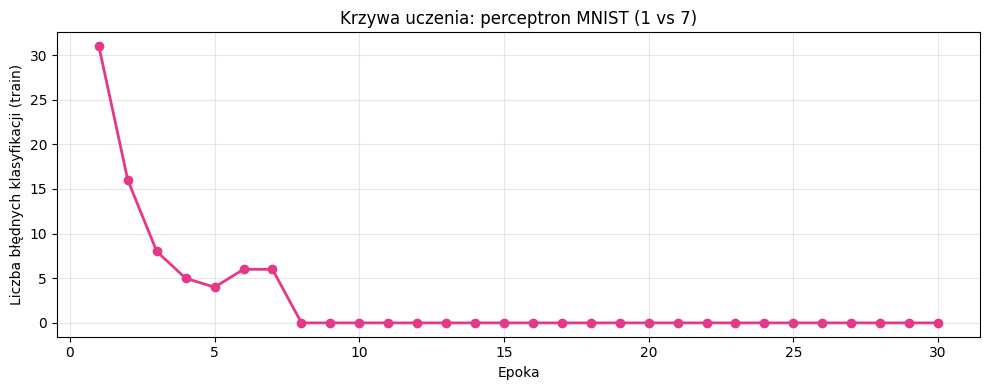

=== Wyniki: 1 vs 7 ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Confusion matrix:
                    pred=1(-1)   pred=7(+1)
actual=1 (-1):        104              0
actual=7 (+1):          0            103


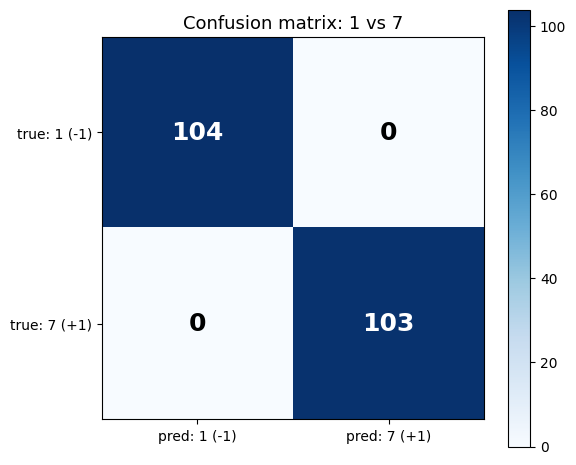

(Uruchom najpierw sekcje 5-6 zeby porownac z modelem 3 vs 4)


In [24]:
# Zadanie 2 — inna para cyfr MNIST
# Wybieramy 6 vs 7 (podobne ksztalty)

DIGIT_A = 6   # etykieta -1
DIGIT_B = 7   # etykieta +1

# 1. Filtracja z train_df i test_df
mask_train2 = train_df["label"].isin([DIGIT_A, DIGIT_B])
mask_test2  = test_df["label"].isin([DIGIT_A, DIGIT_B])

train2 = train_df[mask_train2].copy()
test2  = test_df[mask_test2].copy()

print(f"Train: {len(train2)} próbek  |  Test: {len(test2)} próbek")

# 2. Binaryzacja etykiet: DIGIT_A -> -1, DIGIT_B -> +1
X_train2 = train2.drop("label", axis=1).values
y_train2 = np.where(train2["label"].values == DIGIT_A, -1, 1)

X_test2 = test2.drop("label", axis=1).values
y_test2  = np.where(test2["label"].values == DIGIT_A, -1, 1)

# 3. Normalizacja /255
X_train2 = X_train2 / 255.0
X_test2  = X_test2  / 255.0

print(f"Klasy w y_train2: {np.unique(y_train2, return_counts=True)}")

# 4. Trening
model2 = Perceptron(eta=0.01, n_iter=30)
print("Trenuje perceptron na MNIST (cyfry 0 vs 1)...")
model2.fit(X_train2, y_train2)
print("Gotowe.")
print(f"Błędy per epoka: {model2.errors_}")

# Krzywa błędu
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(model2.errors_) + 1), model2.errors_,
         marker="o", color="#E63888", linewidth=2, markersize=6)
plt.xlabel("Epoka")
plt.ylabel("Liczba błędnych klasyfikacji (train)")
plt.title(f"Krzywa uczenia: perceptron MNIST ({DIGIT_A} vs {DIGIT_B})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Ewaluacja na zbiorze testowym
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred2 = model2.predict(X_test2)

acc  = accuracy_score(y_test2, y_pred2)
prec = precision_score(y_test2, y_pred2)
rec  = recall_score(y_test2, y_pred2)
f1   = f1_score(y_test2, y_pred2)

print(f"=== Wyniki: {DIGIT_A} vs {DIGIT_B} ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Confusion matrix — liczbowa
cm2 = confusion_matrix(y_test2, y_pred2)
print(f"Confusion matrix:")
print(f"                    pred={DIGIT_A}(-1)   pred={DIGIT_B}(+1)")
print(f"actual={DIGIT_A} (-1):     {cm2[0,0]:>6}         {cm2[0,1]:>6}")
print(f"actual={DIGIT_B} (+1):     {cm2[1,0]:>6}         {cm2[1,1]:>6}")

# Confusion matrix — wizualna
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm2, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([f"pred: {DIGIT_A} (-1)", f"pred: {DIGIT_B} (+1)"])
ax.set_yticklabels([f"true: {DIGIT_A} (-1)", f"true: {DIGIT_B} (+1)"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm2[i, j]), ha="center", va="center",
                fontsize=18, fontweight="bold",
                color="white" if cm2[i, j] > cm2.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.title(f"Confusion matrix: {DIGIT_A} vs {DIGIT_B}", fontsize=13)
plt.tight_layout()
plt.show()

# Porownanie z 3 vs 4 (z wczesniejszego modelu)
try:
    acc_34 = accuracy_score(y_test, model_mnist.predict(X_test))
    print(f"=== Porownanie ===")
    print(f"Cyfry  3 vs 4:  accuracy = {acc_34:.4f}")
    print(f"Cyfry {DIGIT_A} vs {DIGIT_B}: accuracy = {acc:.4f}")
    diff = acc - acc_34
    if diff > 0:
        print(f"Para {DIGIT_A} vs {DIGIT_B} jest LATWIEJSZA o {diff:.4f}")
    else:
        print(f"Para {DIGIT_A} vs {DIGIT_B} jest TRUDNIEJSZA o {abs(diff):.4f}")
except NameError:
    print("(Uruchom najpierw sekcje 5-6 zeby porownac z modelem 3 vs 4)")

### Zadanie 3 (challenge): Trudna para

Wytrenuj perceptron na parze cyfr które wyglądają **podobnie**: np. **1 vs 7** albo **3 vs 8**.

**Pytania do przemyślenia:**
- Czy krzywa błędu spada do zera? Jeśli nie — co to mówi o liniowej separowalności tych cyfr w 784D?
- Jak wygląda accuracy w porównaniu z łatwiejszą parą?
- Który rodzaj błędów dominuje w confusion matrix (FP czy FN)?

Train: 1066 próbek  |  Test: 207 próbek
Trenuje perceptron na MNIST (1 vs 7)...
Gotowe.
Błędy per epoka: [31, 16, 8, 5, 4, 6, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


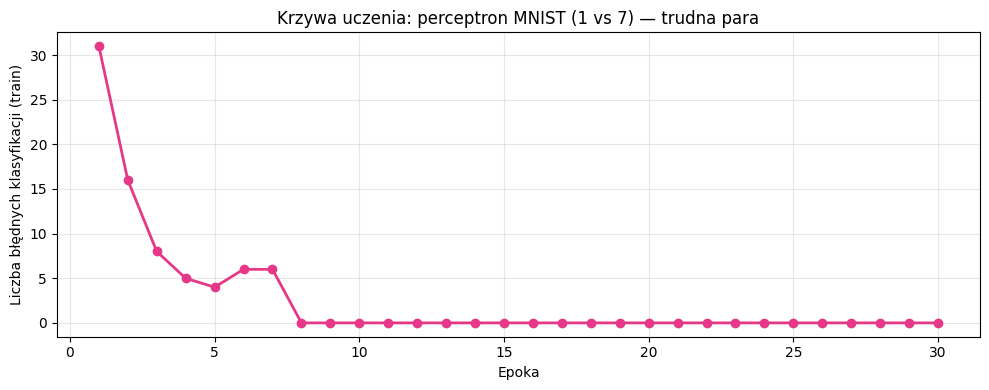


=== Wyniki: 1 vs 7 ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


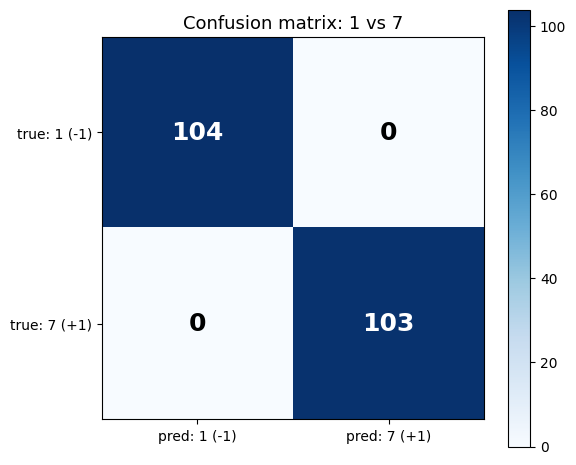


=== Analiza ===
Krzywa bledu osiagnela 0 — dane sa liniowo separowalne.
(Uruchom sekcje 5-6 zeby porownac z modelem 3 vs 4)


In [26]:
# Zadanie 3 — trudna para: 1 vs 7

DIGIT_A = 1   # etykieta -1
DIGIT_B = 7   # etykieta +1

# 1. Filtracja
mask_train3 = train_df["label"].isin([DIGIT_A, DIGIT_B])
mask_test3  = test_df["label"].isin([DIGIT_A, DIGIT_B])

train3 = train_df[mask_train3].copy()
test3  = test_df[mask_test3].copy()

print(f"Train: {len(train3)} próbek  |  Test: {len(test3)} próbek")

# 2. Binaryzacja etykiet: DIGIT_A -> -1, DIGIT_B -> +1
X_train3 = train3.drop("label", axis=1).values
y_train3  = np.where(train3["label"].values == DIGIT_A, -1, 1)

X_test3 = test3.drop("label", axis=1).values
y_test3  = np.where(test3["label"].values == DIGIT_A, -1, 1)

# 3. Normalizacja /255
X_train3 = X_train3 / 255.0
X_test3  = X_test3  / 255.0

# 4. Trening
model3 = Perceptron(eta=0.01, n_iter=30)
print(f"Trenuje perceptron na MNIST ({DIGIT_A} vs {DIGIT_B})...")
model3.fit(X_train3, y_train3)
print("Gotowe.")
print(f"Błędy per epoka: {model3.errors_}")

# Krzywa błędu
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(model3.errors_) + 1), model3.errors_,
         marker="o", color="#E63888", linewidth=2, markersize=6)
plt.xlabel("Epoka")
plt.ylabel("Liczba błędnych klasyfikacji (train)")
plt.title(f"Krzywa uczenia: perceptron MNIST ({DIGIT_A} vs {DIGIT_B}) — trudna para")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Ewaluacja
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred3 = model3.predict(X_test3)

acc3  = accuracy_score(y_test3, y_pred3)
prec3 = precision_score(y_test3, y_pred3)
rec3  = recall_score(y_test3, y_pred3)
f13   = f1_score(y_test3, y_pred3)

print(f"\n=== Wyniki: {DIGIT_A} vs {DIGIT_B} ===")
print(f"Accuracy:  {acc3:.4f}")
print(f"Precision: {prec3:.4f}")
print(f"Recall:    {rec3:.4f}")
print(f"F1-score:  {f13:.4f}")

# Confusion matrix — wizualna
cm3 = confusion_matrix(y_test3, y_pred3)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm3, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([f"pred: {DIGIT_A} (-1)", f"pred: {DIGIT_B} (+1)"])
ax.set_yticklabels([f"true: {DIGIT_A} (-1)", f"true: {DIGIT_B} (+1)"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm3[i, j]), ha="center", va="center",
                fontsize=18, fontweight="bold",
                color="white" if cm3[i, j] > cm3.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.title(f"Confusion matrix: {DIGIT_A} vs {DIGIT_B}", fontsize=13)
plt.tight_layout()
plt.show()

# Analiza trudności
print("\n=== Analiza ===")
if min(model3.errors_) > 0:
    print("Krzywa bledu nigdy nie osiagnela 0 — dane NIE sa liniowo separowalne w 784D.")
    print("Perceptron oscyluje, bo jedynki i siodemki maja wspolna pionowa kreske.")
else:
    print("Krzywa bledu osiagnela 0 — dane sa liniowo separowalne.")

# Porownanie z 3 vs 4
try:
    acc_34 = accuracy_score(y_test, model_mnist.predict(X_test))
    print(f"\nPorownanie accuracy:")
    print(f"  3 vs 4:  {acc_34:.4f}")
    print(f"  1 vs 7:  {acc3:.4f}")
    diff = acc3 - acc_34
    if diff < 0:
        print(f"  => Para 1 vs 7 jest TRUDNIEJSZA o {abs(diff):.4f}")
    else:
        print(f"  => Para 1 vs 7 jest LATWIEJSZA o {diff:.4f}")
except NameError:
    print("(Uruchom sekcje 5-6 zeby porownac z modelem 3 vs 4)")


### Zadanie 4 (opcjonalne): Własna cyfra

Narysuj ręcznie jedną z wybranych cyfr (np. 3 albo 4) w dowolnym programie graficznym. Zapisz jako PNG.

Kroki:
1. Wczytaj przez `PIL.Image.open()`
2. Konwertuj do skali szarości: `.convert('L')`
3. Zmień rozmiar do 28×28: `.resize((28, 28))`
4. Zamień na numpy array i **odwróć kolory** jeśli tło jest białe (MNIST ma czarne tło, białe cyfry)
5. Normalizuj /255
6. Spłaszcz do wektora 784
7. Zrób predykcję przez `model_mnist.predict(...)`

In [25]:
# TODO: Zadanie 4 (opcjonalne) — własna cyfra
# 
# from PIL import Image
# img = Image.open('moja_cyfra.png').convert('L').resize((28, 28))
# img_array = np.array(img)
# 
# # Jeśli tło białe -> odwróć
# if img_array.mean() > 128:
#     img_array = 255 - img_array
# 
# # Normalizuj i spłaszcz
# img_flat = (img_array / 255.0).flatten()
# 
# # Predykcja
# pred = model_mnist.predict(img_flat)
# wynik = DIGIT_A if pred == -1 else DIGIT_B
# print(f'Perceptron twierdzi że to cyfra: {wynik}')
# 
# # Pokaż obraz po preprocessing
# plt.imshow(img_array, cmap='gray')
# plt.title(f'Twoja cyfra (po preprocessing) -> predykcja: {wynik}')
# plt.axis('off')
# plt.show()


---

## 🧠 Sprawdź co umiesz — 6 pytań kontrolnych

Pomyśl 30 sekund nad każdym pytaniem. Nie googluj, nie pytaj sąsiada. To ma być Twoja głowa.

1. **Co robi perceptron geometrycznie w przestrzeni 2D?** (jednym zdaniem)
2. **Dlaczego perceptron nie umie nauczyć się XOR?**
3. **Jak obraz 28×28 staje się wejściem perceptronu?**
4. **Dlaczego dzielimy piksele przez 255?**
5. **Czym różni się precision od recall?**
6. **Gdy accuracy jest 50% — co jest najbardziej prawdopodobną przyczyną?**

---

## 🎯 Jedno zdanie, które musisz zapamiętać

> **Perceptron to linijka, która rysuje prostą w przestrzeni cech, żeby oddzielić dwa rodzaje punktów. Obrazy MNIST to 784-wymiarowa przestrzeń — też można w niej rysować hiperlinijki. Działa dopóki klasy da się oddzielić jedną płaszczyzną.**

---

## Co dalej?

- **Lab 3**: Wielowarstwowe perceptrony (XOR już zadziała! 2 warstwy = nieliniowe granice decyzji)
- **Lab 4**: TensorFlow i klasyfikacja wszystkich 10 cyfr naraz
- **Lab 5**: Sieci konwolucyjne (CNN) — w końcu uwzględniają sąsiedztwo pikseli, rewolucja dla obrazów
- **Lab 6+**: RNN, autoenkodery, GANy, RL

Perceptron jest fundamentem. Jeśli to co robiliśmy dziś Ci zaskoczyło — reszta semestru będzie prosta.